In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold

from tqdm.notebook import tqdm

random_state=809

In [2]:
def plot_cv_indices(cv, X, y, n_splits, lw=10):
    fig, ax = plt.subplots(figsize = (15,8))
    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(range(len(indices)), [ii + .5] * len(indices),
                   c=indices, marker='_', lw=lw, cmap=plt.cm.coolwarm,
                   vmin=-.2, vmax=1.2)

    # Plot the data classes
    ax.scatter(range(len(X)), [ii + 1.5] * len(X), c=y, marker='_', lw=lw, cmap=plt.cm.Paired)

    # Formatting
    yticklabels = list(range(n_splits)) + ['Class']
    ax.set(yticks=np.arange(n_splits+1) + .5, yticklabels=yticklabels,
           xlabel='Sample index', ylabel="CV iteration",
           ylim=[n_splits+2.2, -.2])
    ax.set_title('{}'.format(type(cv).__name__), fontsize=15)
    return ax

def show_images():
    plt.gray() 
    fig, ax = plt.subplots(nrows = 2, ncols=5, figsize=(15,10))
    ax=ax.flatten()
    for index in range(0, 10):
        ax[index].matshow(datasets.load_digits().images[index]) 

# Load Dataset

In [3]:
X_digits, y_digits = datasets.load_digits(return_X_y=True)
df = pd.DataFrame(X_digits, columns = [f'Pixel {nb}' for nb in range(len(X_digits[0]))])
df['y'] = y_digits
df

,Pixel 0,Pixel 1,Pixel 2,Pixel 3,Pixel 4,Pixel 5,Pixel 6,Pixel 7,Pixel 8,Pixel 9,...,Pixel 55,Pixel 56,Pixel 57,Pixel 58,Pixel 59,Pixel 60,Pixel 61,Pixel 62,Pixel 63,y
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


<Figure size 432x288 with 0 Axes>

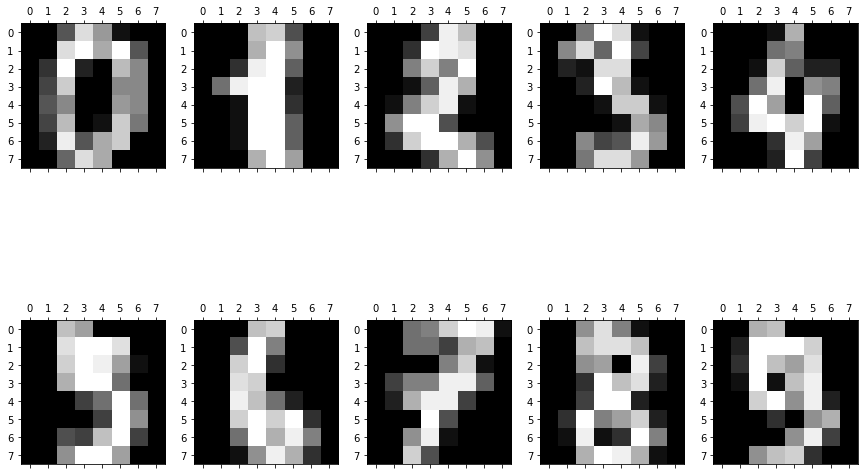

In [4]:
show_images()

# Create the out-of-sample test set 

In [5]:
test_size = 0.33
X_IS, X_OOS, y_IS, y_OOS = train_test_split(X_digits, y_digits, 
                                                        test_size=test_size, 
                                                        random_state=random_state)

# Setting Up the Cross-Validation

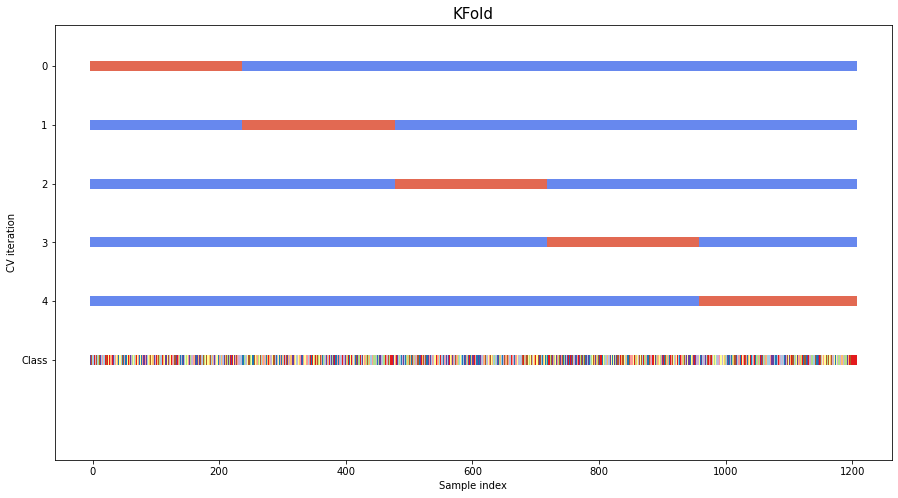

In [6]:
n_splits = 5
shuffle = False
cv = KFold(n_splits=n_splits, shuffle=shuffle)
plot = plot_cv_indices(cv, X_IS, y_IS, n_splits)

# Training a KNN

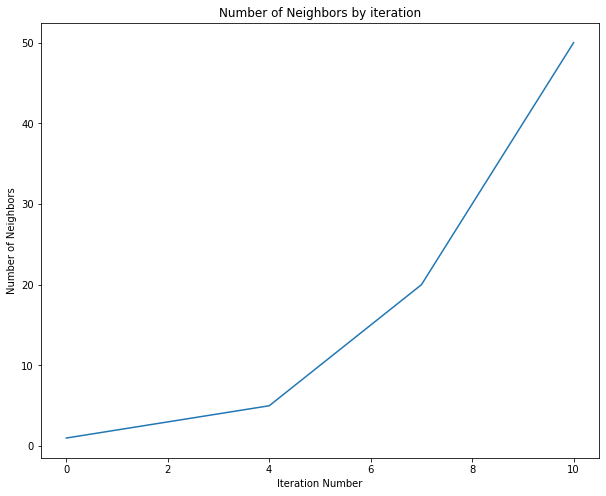

In [7]:
#And the parameter grid over which to optimize
param_grid = [{'n_neighbors': [1, 2, 3, 4, 5, 10, 15, 20, 30, 40, 50]}]

fig, ax = plt.subplots(figsize=(10,8))
x = range(len(param_grid[0]['n_neighbors']))
ax.plot(x, param_grid[0]['n_neighbors'], label = 'Training Set')
ax.set_ylabel('Number of Neighbors')
ax.set_xlabel('Iteration Number')
ax.set_title('Number of Neighbors by iteration')
plt.show()

## Frirst way: Through a Loop

In [8]:
scores = []
for n_neighbors in tqdm(param_grid[0]['n_neighbors']):
    cv_scores = []
    for train_index, test_index in cv.split(X_IS):
        
        #Define the training and validation sets
        X_train, X_validation, y_train, y_validation = X_IS[train_index], X_IS[test_index], \
                                        y_IS[train_index], y_IS[test_index]
        
        #Traing the model with the penalty term
        model_type = KNeighborsRegressor(n_neighbors=n_neighbors)
        
        model = model_type.fit(X_train, y_train)    

        #Record the score for that fold
        validation_score = model.score(X_validation,y_validation)
        cv_scores.append(validation_score)
    
    #Average the CV scores and record
    scores.append([n_neighbors, np.average(cv_scores)])
scores

  0%|          | 0/11 [00:00<?, ?it/s]

[[1, 0.942753973903349],
 [2, 0.9555185366599975],
 [3, 0.9536886422681071],
 [4, 0.9494719192038747],
 [5, 0.9443271352421121],
 [10, 0.9240915217379954],
 [15, 0.9035521061410969],
 [20, 0.8876216355548742],
 [30, 0.8570907609855878],
 [40, 0.8257213547424259],
 [50, 0.7913440897499898]]

In [9]:
def plot_cv_error_KNN(df):
    fix, ax = plt.subplots(figsize=(15,10))
    ax.plot(df_scores['avg_score'])
    ax.set_xlabel('Number of neighbors', fontsize=18)
    ax.set_ylabel('Average Cross Validation Score',  fontsize=18)

    ymax = max(df['avg_score'])
    xpos = df['avg_score'].idxmax()
    xmax = x[xpos]
    
    ax.annotate(f'Max: Neighbors = {xpos}', xy=(xmax, ymax), xytext=(xmax, ymax+0.02),
                arrowprops=dict(facecolor='black', shrink=0.05), fontsize=13)

In [10]:
df_scores = pd.DataFrame(scores, columns =['n_neighbors', 'avg_score'])
df_scores.set_index('n_neighbors', inplace= True)
df_scores

,avg_score
n_neighbors,
1,0.942754
2,0.955519
3,0.953689
4,0.949472
5,0.944327
10,0.924092
15,0.903552
20,0.887622
30,0.857091


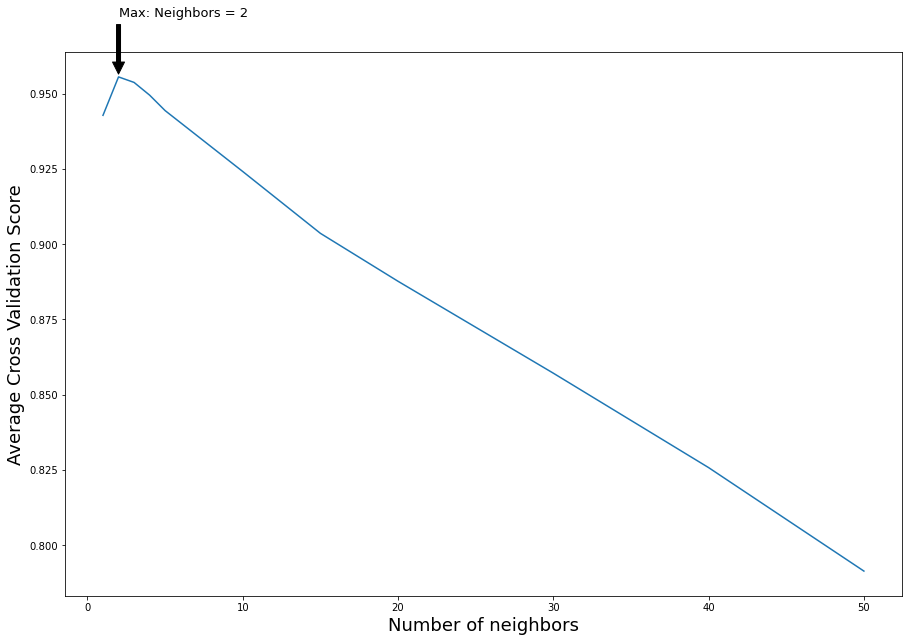

In [11]:
plot_cv_error_KNN(df_scores)

## Second Way: With GridSearchCV

In [12]:
param_grid = [{'n_neighbors': [1, 2, 3, 4, 5, 10, 15, 20, 30, 40, 50]}]
KNN = KNeighborsRegressor()

grid_cv = GridSearchCV(estimator=KNN, cv=cv, param_grid=param_grid, n_jobs = -1)
grid_cv.fit(X_IS, y_IS)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid=[{'n_neighbors': [1, 2, 3, 4, 5, 10, 15, 20, 30, 40,
                                          50]}])

In [13]:
df_scores = pd.DataFrame()
df_scores['n_neighbors'] = param_grid[0]['n_neighbors']
df_scores['avg_score'] = grid_cv.cv_results_['mean_test_score']
df_scores.set_index('n_neighbors', inplace= True)
df_scores

,avg_score
n_neighbors,
1,0.942754
2,0.955519
3,0.953689
4,0.949472
5,0.944327
10,0.924092
15,0.903552
20,0.887622
30,0.857091


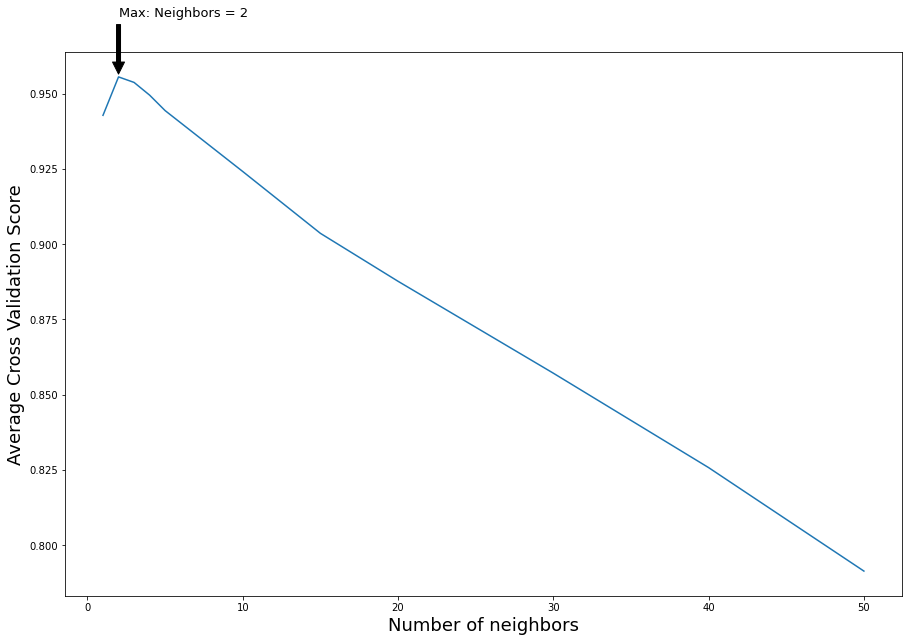

In [14]:
plot_cv_error_KNN(df_scores)